# Cross-generation GPU sweep: exploratory hardware map

## tl;dr

This preregistered exploratory sweep measures the same tiny, compiled agent
transition on six Modal GPU classes, from T4 through H100, plus the local GTX
reference. The cloud matrix contains 2,592 new timed observations; all
completed, all numerical-validity checks passed, and no repetition is removed.

The result is deliberately non-monotonic. In the one-step regime, A100-80GB,
H100, and L40S do not beat their colocated tuned CPU by 256 agents. With 64
transitions fused, every cloud GPU wins at the smallest tested population,
eight agents. At `N=256,H=64`, the cheapest measured option is T4—not H100—and
its GPU-only marginal cost is roughly one eighth of H100's under the
time-stamped Modal rates.

This notebook is an exploratory hardware map. Several cloud runs have high
within-cell variance, so the fresh-container replication in
`preregistration/pilot-012.md` is the confirmatory result.

## Frozen design

All cards run `W=8`, `A=1`, `N ∈ {8,16,32,64,128,256}`, and 64 total
transitions per repetition. `H=1` launches the compiled transition 64 times;
`H=64` executes one compiled 64-transition graph. Both resident and
host-visible GPU modes are measured, along with compiled CPU at one and eight
threads. Nine repetitions follow five warm-ups. Cross-card comparisons use
absolute synchronized wall time and cost; within-card speedup uses the faster
colocated CPU median because cloud CPU placement is not controlled.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

cells = pd.read_csv(PROCESSED / "hardware-sweep-cell-summary.csv")
speedups = pd.read_csv(PROCESSED / "hardware-sweep-speedups.csv")
crossovers = pd.read_csv(PROCESSED / "hardware-sweep-crossovers.csv")
cost = pd.read_csv(PROCESSED / "hardware-sweep-gpu-cost.csv")
quality = pd.read_csv(PROCESSED / "hardware-sweep-run-quality.csv")
fusion = pd.read_csv(PROCESSED / "hardware-sweep-temporal-fusion.csv")
manifest = json.loads((PROCESSED / "hardware-sweep-analysis-manifest.json").read_text())

GPU_ORDER = ["T4", "L4", "A10", "L40S", "A100-80GB", "H100!"]
GPU_COLORS = {
    "T4": "#6B7280",
    "L4": "#0B6E75",
    "A10": "#2563EB",
    "L40S": "#7C3AED",
    "A100-80GB": "#D97706",
    "H100!": "#DC2626",
}
sns.set_theme(style="whitegrid", context="notebook")
manifest["hypotheses"]

{'G1_all_datacenter_resident_h64_cross_at_n8': True,
 'G2_all_datacenter_resident_h1_cross_by_n256': False,
 'G3_h64_proportional_fusion_advantage_gt_1_everywhere': True,
 'G4_cheaper_gpu_beats_h100_cost_in_a_matched_cell': True,
 'G5_host_visible_crossover_is_never_smaller': True,
 'complete_expected_modal_gpu_set': True,
 'expected_modal_gpus': ['A10', 'A100-80GB', 'H100!', 'L4', 'L40S', 'T4'],
 'observed_modal_gpus': ['A10', 'A100-80GB', 'H100!', 'L4', 'L40S', 'T4']}

## Data quality and preregistered outcomes

In [2]:
modal_quality = quality[quality["requested_gpu"].notna()].copy()
assert len(modal_quality) == 6
assert (modal_quality["rows"] == 432).all()
assert (modal_quality["cases"] == 48).all()
assert (modal_quality["execution_error_rows"] == 0).all()
assert (modal_quality["duplicate_case_repetitions"] == 0).all()
assert (modal_quality["invalid_shapes"] == 0).all()
assert manifest["hypotheses"]["complete_expected_modal_gpu_set"]
assert manifest["hypotheses"]["G1_all_datacenter_resident_h64_cross_at_n8"]
assert not manifest["hypotheses"]["G2_all_datacenter_resident_h1_cross_by_n256"]
assert manifest["hypotheses"]["G3_h64_proportional_fusion_advantage_gt_1_everywhere"]
assert manifest["hypotheses"]["G4_cheaper_gpu_beats_h100_cost_in_a_matched_cell"]
assert manifest["hypotheses"]["G5_host_visible_crossover_is_never_smaller"]

modal_quality[
    [
        "requested_gpu",
        "hardware",
        "rows",
        "invalid_shapes",
        "median_cell_cv",
        "p90_cell_cv",
        "cells_cv_over_10pct",
    ]
].sort_values("requested_gpu")

,requested_gpu,hardware,rows,invalid_shapes,median_cell_cv,p90_cell_cv,cells_cv_over_10pct
3,A10,NVIDIA A10,432,0,0.050983,0.264839,20
5,A100-80GB,NVIDIA A100 80GB PCIe,432,0,0.176001,0.343791,25
6,H100!,NVIDIA H100 80GB HBM3,432,0,0.066483,0.353469,23
1,L4,NVIDIA L4,432,0,0.027698,0.082510,2
4,L40S,NVIDIA L40S,432,0,0.092536,0.391469,24
2,T4,Tesla T4,432,0,0.082059,0.294701,20


The sweep is complete and correctness-clean, but it is not precision-clean:
median cell CV ranges from about 2.8% on L4 to 17.6% on A100, and every newly
sampled card has multiple cells above 10% CV. No point is removed. This is why
the plots below are treated as a hardware-selection map and why the next
experiment uses three fresh placements and 30 repetitions per cell.

## Absolute resident wall time

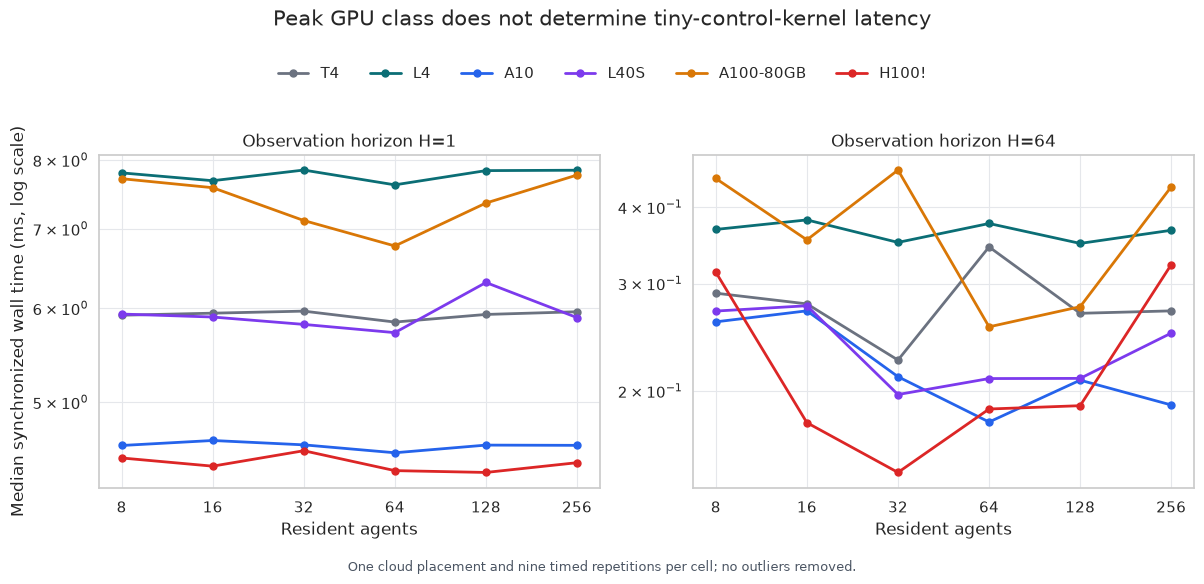

In [3]:
resident = speedups[
    speedups["requested_gpu"].notna()
    & speedups["mode"].eq("compiled-gpu-resident")
    & speedups["shape_valid"]
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
for axis, horizon in zip(axes, [1, 64], strict=True):
    panel = resident[resident["observation_horizon"].eq(horizon)]
    for gpu in GPU_ORDER:
        series = panel[panel["requested_gpu"].eq(gpu)].sort_values("agent_count")
        axis.plot(
            series["agent_count"],
            series["wall_ms_median"],
            marker="o",
            linewidth=2,
            markersize=5,
            color=GPU_COLORS[gpu],
            label=gpu,
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xticks([8, 16, 32, 64, 128, 256])
    axis.set_xticklabels(["8", "16", "32", "64", "128", "256"])
    axis.set_title(f"Observation horizon H={horizon}")
    axis.set_xlabel("Resident agents")
    axis.grid(True, which="both", color="#E5E7EB", linewidth=0.8)
axes[0].set_ylabel("Median synchronized wall time (ms, log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Peak GPU class does not determine tiny-control-kernel latency", y=1.14, fontsize=15)
fig.text(
    0.5,
    -0.03,
    "One cloud placement and nine timed repetitions per cell; no outliers removed.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"hardware-sweep-resident-wall-time.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [4]:
rank_n256 = resident[resident["agent_count"].eq(256)][
    [
        "requested_gpu",
        "observation_horizon",
        "wall_ms_median",
        "device_ms_median",
        "best_cpu_wall_ms_median",
        "speedup_vs_best_cpu",
        "wall_ms_cv",
    ]
].sort_values(["observation_horizon", "wall_ms_median"])
rank_n256

,requested_gpu,observation_horizon,wall_ms_median,device_ms_median,best_cpu_wall_ms_median,speedup_vs_best_cpu,wall_ms_cv
165,H100!,1,4.446104,4.407616,4.215091,0.948041,0.023810
93,A10,1,4.598316,4.560000,4.736964,1.030152,0.018433
117,L40S,1,5.891590,5.850592,5.446479,0.924450,0.041062
69,T4,1,5.958962,5.916928,5.777572,0.969560,0.019844
141,A100-80GB,1,7.768997,7.690944,6.242860,0.803561,0.037245
45,L4,1,7.841887,7.769856,8.874280,1.131651,0.019369
95,A10,64,0.189749,0.166400,0.828578,4.366705,0.187142
119,L40S,64,0.248825,0.199456,0.710326,2.854721,0.140208
71,T4,64,0.270594,0.236864,0.819691,3.029228,0.323664
167,H100!,64,0.322163,0.281408,0.968841,3.007301,0.273718


At `N=256,H=1`, H100 and A10 are fastest in absolute terms, but neither peak
FLOPS nor generation produces a monotone ordering. At `H=64`, A10 is fastest;
T4 is second; H100 is fourth; A100 is slowest. The synchronized CUDA-event
span accounts for nearly all one-step wall time, indicating that the penalty
is on the submitted GPU timeline (many tiny launches and gaps), rather than
the final host synchronization call alone.

## Crossover against the colocated tuned CPU

In [5]:
resident_crossovers = crossovers[
    crossovers["requested_gpu"].notna()
    & crossovers["mode"].eq("compiled-gpu-resident")
][
    [
        "requested_gpu",
        "observation_horizon",
        "smallest_tested_crossover_n_best_cpu",
        "smallest_tested_ci_supported_crossover_n_best_cpu",
        "smallest_sustained_crossover_n_best_cpu",
        "max_valid_speedup_best_cpu",
    ]
].sort_values(["observation_horizon", "requested_gpu"])
resident_crossovers

,requested_gpu,observation_horizon,smallest_tested_crossover_n_best_cpu,smallest_tested_ci_supported_crossover_n_best_cpu,smallest_sustained_crossover_n_best_cpu,max_valid_speedup_best_cpu
1,A10,1,128.0,256.0,128.0,1.030152
5,A100-80GB,1,NaN,NaN,NaN,0.920570
13,H100!,1,NaN,NaN,NaN,0.948041
17,L4,1,16.0,16.0,16.0,1.131651
21,L40S,1,NaN,NaN,NaN,0.928021
25,T4,1,64.0,NaN,NaN,1.011806
3,A10,64,8.0,8.0,8.0,4.366705
7,A100-80GB,64,8.0,8.0,8.0,2.639756
15,H100!,64,8.0,8.0,8.0,4.712752
19,L4,64,8.0,8.0,8.0,3.557256


Every fused GPU path crosses at `N=8`. The one-step hypothesis fails: A100,
H100, and L40S never cross; T4 has a non-sustained median win at 64; A10 first
crosses at 128 but gains bootstrap support only at 256; L4 crosses at 16 and
stays above one. Because each card can be paired with a different CPU family,
these speedups answer a deployment question (“GPU or this colocated CPU?”),
not a pure cross-GPU architecture question.

## Time-stamped GPU-only marginal cost

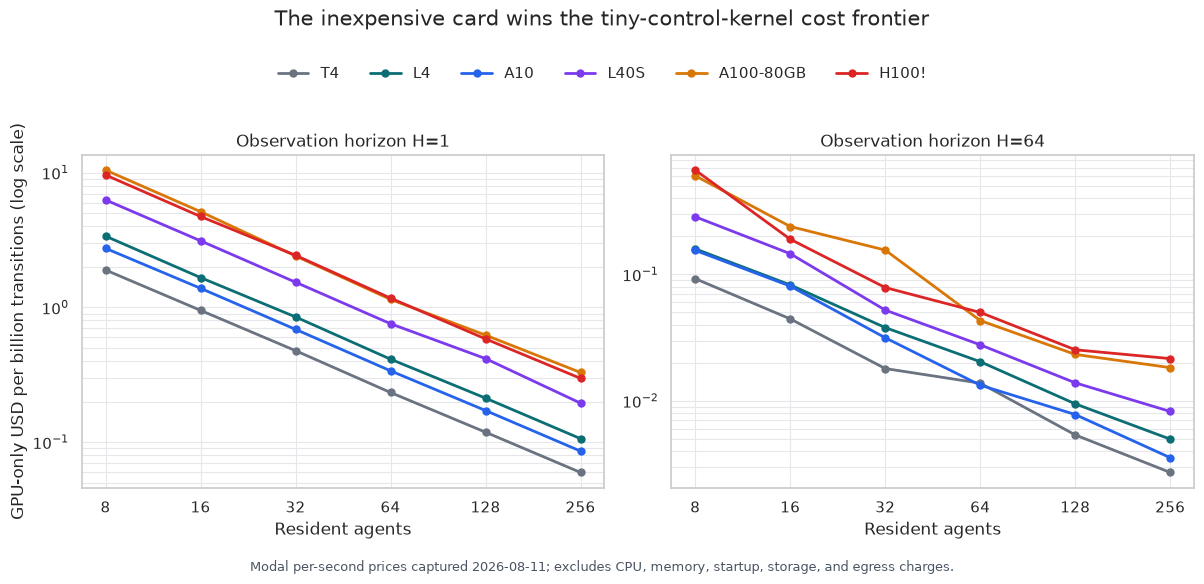

In [6]:
resident_cost = cost[
    cost["requested_gpu"].notna()
    & cost["mode"].eq("compiled-gpu-resident")
    & cost["shape_valid"]
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
for axis, horizon in zip(axes, [1, 64], strict=True):
    panel = resident_cost[resident_cost["observation_horizon"].eq(horizon)]
    for gpu in GPU_ORDER:
        series = panel[panel["requested_gpu"].eq(gpu)].sort_values("agent_count")
        axis.plot(
            series["agent_count"],
            series["gpu_cost_usd_per_billion_agent_steps"],
            marker="o",
            linewidth=2,
            markersize=5,
            color=GPU_COLORS[gpu],
            label=gpu,
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xticks([8, 16, 32, 64, 128, 256])
    axis.set_xticklabels(["8", "16", "32", "64", "128", "256"])
    axis.set_title(f"Observation horizon H={horizon}")
    axis.set_xlabel("Resident agents")
    axis.grid(True, which="both", color="#E5E7EB", linewidth=0.8)
axes[0].set_ylabel("GPU-only USD per billion transitions (log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("The inexpensive card wins the tiny-control-kernel cost frontier", y=1.14, fontsize=15)
fig.text(
    0.5,
    -0.03,
    "Modal per-second prices captured 2026-08-11; excludes CPU, memory, startup, storage, and egress charges.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"hardware-sweep-gpu-cost.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [7]:
cost_n256 = resident_cost[resident_cost["agent_count"].eq(256)][
    [
        "requested_gpu",
        "observation_horizon",
        "gpu_price_usd_per_second",
        "wall_ms_median",
        "gpu_cost_usd_per_billion_agent_steps",
    ]
].sort_values(
    ["observation_horizon", "gpu_cost_usd_per_billion_agent_steps"]
)
cost_n256

,requested_gpu,observation_horizon,gpu_price_usd_per_second,wall_ms_median,gpu_cost_usd_per_billion_agent_steps
131,T4,1,0.000164,5.958962,0.059648
11,A10,1,0.000306,4.598316,0.085882
83,L4,1,0.000222,7.841887,0.106256
107,L40S,1,0.000542,5.891590,0.194900
59,H100!,1,0.001097,4.446104,0.297691
35,A100-80GB,1,0.000694,7.768997,0.329082
143,T4,64,0.000164,0.270594,0.002709
23,A10,64,0.000306,0.189749,0.003544
95,L4,64,0.000222,0.366731,0.004969
119,L40S,64,0.000542,0.248825,0.008231


At `N=256,H=64`, the exploratory cost ranking is T4, A10, L4, L40S, A100,
H100. T4 costs about `$0.00271` per billion steady-state transitions and H100
about `$0.02157` under the captured GPU rates. This is marginal runtime cost,
not total job cost; cold compilation is seconds to tens of seconds and can
dominate short-lived jobs.

## Mechanism and limits

In [8]:
fusion.groupby(["requested_gpu", "mode"])[
    "gpu_proportional_fusion_advantage"
].agg(["min", "median", "max"]).sort_index()

min    median       max
requested_gpu mode                                                   
A10           compiled-gpu-host-visible  2.676483  3.216645  3.826762
              compiled-gpu-resident      2.464190  3.060584  4.238895
A100-80GB     compiled-gpu-host-visible  2.086927  2.656326  3.825261
              compiled-gpu-resident      1.982879  2.688298  2.984269
H100!         compiled-gpu-host-visible  1.864111  2.517533  3.969324
              compiled-gpu-resident      2.195634  3.049045  5.529275
L4            compiled-gpu-host-visible  3.182370  3.483276  4.252882
              compiled-gpu-resident      2.363466  2.701707  3.143421
L40S          compiled-gpu-host-visible  2.371517  2.947641  4.003927
              compiled-gpu-resident      1.765434  2.485534  3.374858
T4            compiled-gpu-host-visible  3.284246  3.559502  3.659060
              compiled-gpu-resident      2.229950  3.053107  3.371772

1. **Temporal regularity matters more than peak hardware.** Every card gains
   proportionally more from `H=64` than its tuned CPU at every population.
2. **High-end hardware can be the wrong economic choice for tiny kernels.** A
   T4/A10-class card can occupy the cost frontier even when H100 has lower
   absolute one-step latency.
3. **The result is framework-specific.** PyTorch Inductor is a useful matched
   path, not a custom-kernel ceiling. CUDA Graphs, Triton/CUDA kernels, and a
   persistent work queue are required baselines.
4. **The cloud host is a confounder.** Colocated CPU speedups should never be
   ranked across cards as if CPU hosts were identical.
5. **One placement is insufficient for hardware claims.** The confirmatory
   three-placement experiment is preregistered and preserves all variation.
6. **Hardware eligibility is not workload eligibility.** The trace-replay
   ceiling remains necessary: a crossover at eight agents is useless when
   fewer than eight same-route transitions become ready before the deadline.